## Notebook 12 - Graph Neural Networks for Match Outcome Prediction
Núria Pascual Salas

**Goal:** Predict match outcomes (Win / Draw / Loss) directly from each team's
match-level passing network, using a Graph Convolutional Network (GCN).

**Method:**
- One graph per team-match (node = player, directed edge = completed pass).
- Node features: in-degree, out-degree, in-strength, out-strength, PageRank,
  betweenness, eigenvector centrality (standardised across all graphs).
- Target: match outcome from the team's perspective (Win=2, Draw=1, Loss=0).
- Model: two GCNConv layers + global mean pooling + linear classifier
  (1,411 parameters).
- Evaluation: 5-fold cross-validation grouped by match (`StratifiedGroupKFold`),
  so the two team-graphs of the same fixture never fall on different sides of a
  split. Reported as mean ± std across folds, with a label-permutation test.

**Result (reported in the thesis):** CV accuracy 0.455 ± 0.045, macro-AUC
0.617 ± 0.019, permutation p = 0.010.

**Config flags:**
- `USE_SF = True`: concatenates the team Switching Factor to the pooled graph
  vector before the classifier. Does not improve the result (0.434), so not used
  in the thesis.
- `USE_EDGE_WEIGHTS = True`: uses pass counts as convolution edge weights. Does
  not improve the result (0.429), so not used in the thesis.

Both flags are `False` by default, which reproduces the reported result.

In [1]:
from utils import *
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')

Device: cpu
PyTorch version: 2.12.0+cpu


### 1. Build match-level passing networks

In [ ]:
def network_to_pyg_data(G, label, sf_value):
    """Convert a networkx DiGraph into a PyG Data object.
    Node features: 7 standard centrality metrics.
    """
    if G.number_of_nodes() < 2 or G.number_of_edges() < 1:
        return None

    nodes = list(G.nodes())
    n = len(nodes)
    node_idx = {p: i for i, p in enumerate(nodes)}

    # Node features
    try:
        pr = nx.pagerank(G, weight='weight')
    except Exception:
        pr = {p: 1.0/n for p in nodes}

    try:
        # Inverted weights for betweenness
        G_inv = G.copy()
        for u, v in G_inv.edges():
            G_inv[u][v]['weight'] = 1.0 / G_inv[u][v]['weight']
        bt = nx.betweenness_centrality(G_inv, weight='weight')
    except Exception:
        bt = {p: 0.0 for p in nodes}

    try:
        ec = nx.eigenvector_centrality_numpy(G.to_undirected(), weight='weight')
    except Exception:
        ec = {p: 0.0 for p in nodes}

    in_deg  = dict(G.in_degree())
    out_deg = dict(G.out_degree())
    in_str  = dict(G.in_degree(weight='weight'))
    out_str = dict(G.out_degree(weight='weight'))

    x_list = []
    for p in nodes:
        x_list.append([
            in_deg.get(p, 0),
            out_deg.get(p, 0),
            in_str.get(p, 0),
            out_str.get(p, 0),
            pr.get(p, 0),
            bt.get(p, 0),
            ec.get(p, 0),
        ])
    x = torch.tensor(x_list, dtype=torch.float)

    edge_index = []
    edge_weight = []
    for u, v, d in G.edges(data=True):
        edge_index.append([node_idx[u], node_idx[v]])
        edge_weight.append(d.get('weight', 1.0))
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)

    y = torch.tensor([label], dtype=torch.long)

    sf = torch.tensor([[sf_value]], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_weight=edge_weight, y=y, sf=sf)


def result_to_label(result):
    """Map result string to integer label."""
    if result == 'win':
        return 2
    elif result == 'draw':
        return 1
    else:
        return 0  # lost


# We build all team-match graphs
graphs = []
metadata = []

print('Building match-level graphs...')
for team_id, team_name in all_teams.items():
    n_matches = 0
    for m_id, events in stream_matches_from_zip(zip_path, folder_laliga, '_events.json'):
        teams_in_match = {e['team']['id'] for e in events if 'team' in e}
        if team_id not in teams_in_match:
            continue

        G = build_passing_network(events, team_name)
        _, _, result, _ = get_match_result(events, team_id)
        if G.number_of_nodes() < 5 or result is None:
            continue
        
        sf_value = calculate_match_sf(events, team_id)

        label = result_to_label(result)
        data = network_to_pyg_data(G, label, sf_value)
        if data is None:
            continue

        graphs.append(data)
        metadata.append({
            'team': team_name,
            'team_id': team_id,
            'match_id': m_id,
            'result': result,
            'label': label,
        })
        n_matches += 1
    print(f'  {team_name}: {n_matches} matches')

print(f'\nTotal graphs: {len(graphs)}')
labels = [g.y.item() for g in graphs]
print(f'Label distribution: W={labels.count(2)}, D={labels.count(1)}, L={labels.count(0)}')

Building match-level graphs...
  Deportivo Alavés: 38 matches
  Granada: 38 matches
  Barcelona: 38 matches
  Almería: 38 matches
  Sevilla: 38 matches
  Cádiz: 38 matches
  Girona: 38 matches
  Athletic Club: 38 matches
  Real Sociedad: 38 matches
  Mallorca: 38 matches
  Real Betis: 38 matches
  Atlético Madrid: 38 matches
  Villarreal: 38 matches
  Celta Vigo: 38 matches
  Valencia: 38 matches
  Las Palmas: 38 matches
  Osasuna: 38 matches
  Real Madrid: 38 matches
  Getafe: 38 matches
  Rayo Vallecano: 38 matches

Total graphs: 760
Label distribution: W=277, D=206, L=277


### 2. Normalize node features

In [ ]:
all_x = torch.cat([g.x for g in graphs], dim=0)
mean = all_x.mean(dim=0)
std = all_x.std(dim=0)
std[std == 0] = 1.0

for g in graphs:
    g.x = (g.x - mean) / std

print('Node features normalized (z-score per feature).')
print(f'Feature dim: {graphs[0].x.shape[1]}')

Node features normalized (z-score per feature).
Feature dim: 7


### 3. GCN model definition

In [4]:
class GCN(nn.Module):
    """2-layer GCN + global mean pooling + linear head.
    If use_sf=True, the team Switching Factor is concatenated to the pooled
    graph embedding before the final classifier.
    Edge weights (pass counts) are used in the convolution only when an
    edge_weight tensor is passed (controlled by USE_EDGE_WEIGHTS)."""
    def __init__(self, in_dim, hidden_dim, n_classes, dropout=0.5, use_sf=False):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        extra = 1 if use_sf else 0
        self.classifier = nn.Linear(hidden_dim + extra, n_classes)
        self.dropout = dropout
        self.use_sf = use_sf

    def forward(self, x, edge_index, batch, edge_weight=None, sf=None):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_weight)
        x = F.relu(x)

        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)

        if self.use_sf:
            x = torch.cat([x, sf], dim=1)
        return self.classifier(x)


### 4. Cross-validation configuration

In [ ]:
USE_SF            = False   # True for the SF variant, False for the base GCN
USE_EDGE_WEIGHTS  = False   # True uses pass counts as convolution edge weights (robustness check)
N_SPLITS     = 5
N_EPOCHS     = 80
BATCH_SIZE   = 32
LR           = 1e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM   = 32
SEED         = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

labels_array = np.array([g.y.item() for g in graphs])
groups_array = np.array([m['match_id'] for m in metadata])
assert len(labels_array) == len(groups_array) == len(graphs)

print(f'Total graphs: {len(graphs)}')
print(f'Label distribution: {Counter(labels_array.tolist())}')
print(f'Unique matches (groups): {len(set(groups_array))}')
print(f'USE_SF = {USE_SF}')
print(f'USE_EDGE_WEIGHTS = {USE_EDGE_WEIGHTS}')

Total graphs: 760
Label distribution: Counter({2: 277, 0: 277, 1: 206})
Unique matches (groups): 380
USE_SF = False
USE_EDGE_WEIGHTS = False


### 5. Training and evaluation helpers

In [6]:
def make_model():
    return GCN(in_dim=7, hidden_dim=HIDDEN_DIM, n_classes=3,
               dropout=0.5, use_sf=USE_SF).to(device)


def _forward(model, batch):
    sf = getattr(batch, 'sf', None) if USE_SF else None
    ew = getattr(batch, 'edge_weight', None) if USE_EDGE_WEIGHTS else None
    return model(batch.x, batch.edge_index, batch.batch,
                 edge_weight=ew, sf=sf)


def train_one_fold(train_graphs, val_graphs, epochs=N_EPOCHS):
    """Train a fresh GCN; keep the weights with best validation accuracy."""
    model = make_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_graphs,   batch_size=BATCH_SIZE, shuffle=False)

    best_val, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = _forward(model, batch)
            loss = criterion(out, batch.y)
            loss.backward()
            optimizer.step()
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                pred = _forward(model, batch).argmax(dim=1)
                correct += (pred == batch.y).sum().item()
                total += batch.num_graphs
        val_acc = correct / total
        if val_acc > best_val:
            best_val = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict_probs(model, test_graphs):
    model.eval()
    loader = DataLoader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)
    probs, trues = [], []
    for batch in loader:
        batch = batch.to(device)
        probs.append(F.softmax(_forward(model, batch), dim=1).cpu().numpy())
        trues.append(batch.y.cpu().numpy())
    return np.concatenate(trues), np.concatenate(probs)

### 6. Grouped 5-fold cross-validation

In [7]:
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_acc, fold_auc = [], []
cm_total = np.zeros((3, 3), dtype=int)

print(f'StratifiedGroupKFold ({N_SPLITS} folds), USE_SF={USE_SF}\n')
for k, (trainval_idx, test_idx) in enumerate(
        sgkf.split(graphs, labels_array, groups_array)):

    assert len(set(groups_array[trainval_idx]) & set(groups_array[test_idx])) == 0, \
        'Match leakage between train and test!'

    inner = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=SEED)
    tr_rel, val_rel = next(inner.split(
        np.zeros(len(trainval_idx)),
        labels_array[trainval_idx],
        groups_array[trainval_idx]))
    tr_idx, val_idx = trainval_idx[tr_rel], trainval_idx[val_rel]

    train_graphs = [graphs[i] for i in tr_idx]
    val_graphs   = [graphs[i] for i in val_idx]
    test_graphs  = [graphs[i] for i in test_idx]

    model = train_one_fold(train_graphs, val_graphs)
    y_true, y_prob = predict_probs(model, test_graphs)
    y_pred = y_prob.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except ValueError:
        auc = np.nan
    fold_acc.append(acc)
    fold_auc.append(auc)
    cm_total += confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    print(f'  Fold {k}: acc={acc:.3f}  macro-AUC={auc:.3f}  (test n={len(test_idx)})')

acc_mean, acc_std = np.mean(fold_acc), np.std(fold_acc)
auc_mean, auc_std = np.nanmean(fold_auc), np.nanstd(fold_auc)

print('\n' + '=' * 50)
print(f'CV accuracy : {acc_mean:.3f} ± {acc_std:.3f}')
print(f'CV macro-AUC: {auc_mean:.3f} ± {auc_std:.3f}')
print(f'Random baseline (3 classes): 0.333')
print('=' * 50)

StratifiedGroupKFold (5 folds), USE_SF=False

  Fold 0: acc=0.467  macro-AUC=0.644  (test n=152)
  Fold 1: acc=0.375  macro-AUC=0.601  (test n=152)
  Fold 2: acc=0.500  macro-AUC=0.595  (test n=152)
  Fold 3: acc=0.441  macro-AUC=0.610  (test n=152)
  Fold 4: acc=0.493  macro-AUC=0.633  (test n=152)

CV accuracy : 0.455 ± 0.045
CV macro-AUC: 0.617 ± 0.019
Random baseline (3 classes): 0.333


### 7. Pooled confusion matrix (all folds)

Pooled confusion matrix (summed over folds):
        L_pred  D_pred  W_pred
L_true     166       5     106
D_true      97       3     106
W_true      91       9     177


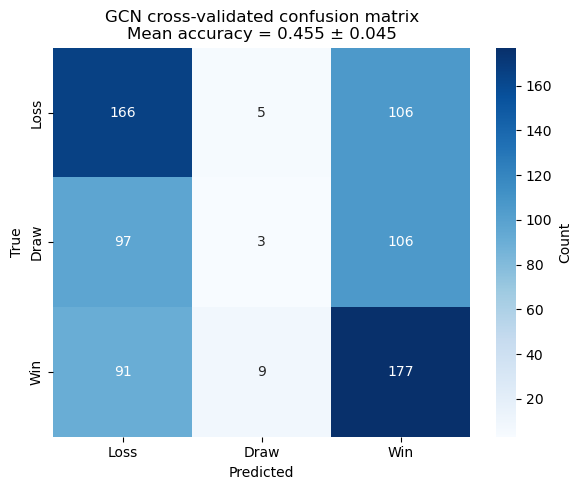

In [ ]:
import seaborn as sns

print('Pooled confusion matrix (summed over folds):')
print(pd.DataFrame(cm_total,
                   index=['L_true', 'D_true', 'W_true'],
                   columns=['L_pred', 'D_pred', 'W_pred']))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Loss', 'Draw', 'Win'],
            yticklabels=['Loss', 'Draw', 'Win'],
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'GCN cross-validated confusion matrix\n'
             f'Mean accuracy = {acc_mean:.3f} ± {acc_std:.3f}')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/gnn_confusion_matrix_cv.png', dpi=130, bbox_inches='tight')
plt.show()

### 8. Permutation test

In [ ]:
N_PERM = 100        
PERM_EPOCHS = 60    

def cv_mean_accuracy(label_vec, epochs=PERM_EPOCHS):
    sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    accs = []
    for trainval_idx, test_idx in sgkf.split(graphs, label_vec, groups_array):
        inner = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=SEED)
        tr_rel, val_rel = next(inner.split(
            np.zeros(len(trainval_idx)),
            label_vec[trainval_idx], groups_array[trainval_idx]))
        tr_idx, val_idx = trainval_idx[tr_rel], trainval_idx[val_rel]

        for i in range(len(graphs)):
            graphs[i].y = torch.tensor([label_vec[i]], dtype=torch.long)

        model = train_one_fold([graphs[i] for i in tr_idx],
                               [graphs[i] for i in val_idx], epochs=epochs)
        y_true, y_prob = predict_probs(model, [graphs[i] for i in test_idx])
        accs.append(accuracy_score(y_true, y_prob.argmax(1)))
    return np.mean(accs)

for i in range(len(graphs)):
    graphs[i].y = torch.tensor([labels_array[i]], dtype=torch.long)

observed = acc_mean
rng = np.random.default_rng(SEED)
null_accs = []
print(f'Running permutation test ({N_PERM} permutations)...')
for p in range(N_PERM):
    perm = labels_array.copy()
    rng.shuffle(perm)
    null_accs.append(cv_mean_accuracy(perm))
    print(f'  perm {p+1}/{N_PERM}: null acc={null_accs[-1]:.3f}')

for i in range(len(graphs)):
    graphs[i].y = torch.tensor([labels_array[i]], dtype=torch.long)

null_accs = np.array(null_accs)
p_value = (np.sum(null_accs >= observed) + 1) / (N_PERM + 1)
print('\n' + '=' * 50)
print(f'Observed CV accuracy: {observed:.3f}')
print(f'Null distribution:    {null_accs.mean():.3f} ± {null_accs.std():.3f}')
print(f'Permutation p-value:  {p_value:.4f}')
print('=' * 50)

Running permutation test (100 permutations)...
  perm 1/100: null acc=0.372
  perm 2/100: null acc=0.364
  perm 3/100: null acc=0.388
  perm 4/100: null acc=0.341
  perm 5/100: null acc=0.349
  perm 6/100: null acc=0.362
  perm 7/100: null acc=0.338
  perm 8/100: null acc=0.339
  perm 9/100: null acc=0.355
  perm 10/100: null acc=0.330
  perm 11/100: null acc=0.354
  perm 12/100: null acc=0.393
  perm 13/100: null acc=0.350
  perm 14/100: null acc=0.330
  perm 15/100: null acc=0.363
  perm 16/100: null acc=0.379
  perm 17/100: null acc=0.375
  perm 18/100: null acc=0.339
  perm 19/100: null acc=0.338
  perm 20/100: null acc=0.337
  perm 21/100: null acc=0.332
  perm 22/100: null acc=0.362
  perm 23/100: null acc=0.333
  perm 24/100: null acc=0.407
  perm 25/100: null acc=0.388
  perm 26/100: null acc=0.341
  perm 27/100: null acc=0.341
  perm 28/100: null acc=0.333
  perm 29/100: null acc=0.362
  perm 30/100: null acc=0.399
  perm 31/100: null acc=0.349
  perm 32/100: null acc=0.366
  

### 9. Save results

In [10]:
results = {
    'n_graphs_total': len(graphs),
    'n_matches':      len(set(groups_array)),
    'use_sf':         USE_SF,
    'use_edge_weights': USE_EDGE_WEIGHTS,
    'n_splits':       N_SPLITS,
    'cv_acc_mean':    round(float(acc_mean), 4),
    'cv_acc_std':     round(float(acc_std), 4),
    'cv_auc_mean':    round(float(auc_mean), 4),
    'cv_auc_std':     round(float(auc_std), 4),
    'random_baseline':round(1/3, 4),
    'perm_p_value':   round(float(p_value), 4),
    'n_perm':         N_PERM,
    'hidden_dim':     HIDDEN_DIM,
    'n_epochs':       N_EPOCHS,
    'batch_size':     BATCH_SIZE,
    'lr':             LR,
}
suffix = ('sf' if USE_SF else 'base') + ('_ew' if USE_EDGE_WEIGHTS else '')
df_results = pd.DataFrame([results])
df_results.to_csv(f'{CSV_DIR}/gnn_results_cv_{suffix}.csv', index=False)
print(df_results.T.to_string())

                       0
n_graphs_total       760
n_matches            380
use_sf             False
use_edge_weights   False
n_splits               5
cv_acc_mean       0.4553
cv_acc_std        0.0453
cv_auc_mean       0.6168
cv_auc_std        0.0186
random_baseline   0.3333
perm_p_value      0.0099
n_perm               100
hidden_dim            32
n_epochs              80
batch_size            32
lr                 0.001
